In [1]:
import pickle

data_path = "../../data/graph/graph_data_library_no_embedding_dict.pkl"
data = pickle.load(open(data_path, "rb"))
data.keys()
company_graph_datas = data["company_graph_datas"]
company_graph_datas.keys()

dict_keys(['PCG|embedding_raw_user_data|oneway_run', 'PCG|embedding_risk_desc_catalog|oneway_run', 'PCG|embedding_summary_user_data|oneway_run', 'PCG|embedding_raw_user_data|twoway_run', 'PCG|embedding_risk_desc_catalog|twoway_run', 'PCG|embedding_summary_user_data|twoway_run', 'lotus_south|embedding_raw_user_data|oneway_run', 'lotus_south|embedding_risk_desc_catalog|oneway_run', 'lotus_south|embedding_summary_user_data|oneway_run', 'lotus_south|embedding_raw_user_data|twoway_run', 'lotus_south|embedding_risk_desc_catalog|twoway_run', 'lotus_south|embedding_summary_user_data|twoway_run'])

In [2]:
import pickle
import networkx as nx
import pandas as pd
import os


# from utils import get_number_edges_to_show
def get_number_edges_to_show(total_nodes):
    return 2 * total_nodes


def filter_non_arrow_edges(edges, slider_value):
    new_edges = []
    for edge in edges:
        # if edge["interdependency_type"] == "Causal":
        if edge["cosine_similarity"] >= slider_value:
            new_edges.append(edge)
    return new_edges


debug_list = []
all_data_list = []
for company, data in company_graph_datas.items():
    if company != "PCG|embedding_risk_desc_catalog|oneway_run":
        continue
    old_G = nx.Graph()
    print(data.keys())
    nodes = data["nodes"]
    edges = data["edges"]
    print(edges[0].keys())
    line_weights = [edge["cosine_similarity"] for edge in edges]
    num_edges_to_show = get_number_edges_to_show(len(nodes))
    sorted_weights = sorted(line_weights, reverse=True)
    # The threshold is the weight of the (num_edges_to_show)-th edge (0-indexed)
    slider_value = sorted_weights[num_edges_to_show - 1]
    filter_edges = filter_non_arrow_edges(edges, slider_value)
    print(len(filter_edges))
    for edge in filter_edges:
        old_G.add_edge(
            edge["risk_a_data"]["label"],
            edge["risk_b_data"]["label"],
            weight=edge["cosine_similarity"],
        )
        if (
            edge["source"] == "risk_PCG_20250513_24"
            or edge["target"] == "risk_PCG_20250513_24"
        ):
            debug_list.append(edge)

dict_keys(['nodes', 'edges', 'number_of_displayed_edges', 'risk_catalog_reference_id', 'overlay_top_n_risks_catalog_id', 'overlay_news_id_list'])
dict_keys(['source', 'target', 'interdependency_type', 'direction', 'rationale', 'confidence', 'risk_a_data', 'risk_b_data', 'distance', 'cosine_similarity', 'high_priority', 'similarity_rank'])
132


In [3]:
import pickle
import networkx as nx
import pandas as pd
import os


# from utils import get_number_edges_to_show
def get_number_edges_to_show(total_nodes):
    return 2 * total_nodes


def filter_non_arrow_edges(edges, slider_value):
    new_edges = []
    for edge in edges:
        if edge["interdependency_type"] == "Causal":
            if edge["cosine_similarity"] >= slider_value:
                new_edges.append(edge)
    return new_edges


debug_list = []
all_data_list = []
edge_name_list = []
for company, data in company_graph_datas.items():
    if company != "PCG|embedding_risk_desc_catalog|oneway_run":
        continue
    G = nx.Graph()
    print(data.keys())
    nodes = data["nodes"]
    edges = data["edges"]
    print(edges[0].keys())
    for edge in edges:
        edge_name_list.append(edge["risk_a_data"]["label"])
        edge_name_list.append(edge["risk_b_data"]["label"])
        G.add_edge(
            edge["risk_a_data"]["label"],
            edge["risk_b_data"]["label"],
            weight=edge["cosine_similarity"],
        )
        if (
            edge["source"] == "risk_PCG_20250513_24"
            or edge["target"] == "risk_PCG_20250513_24"
        ):
            debug_list.append(edge)
edge_name_list = list(set(edge_name_list))

dict_keys(['nodes', 'edges', 'number_of_displayed_edges', 'risk_catalog_reference_id', 'overlay_top_n_risks_catalog_id', 'overlay_news_id_list'])
dict_keys(['source', 'target', 'interdependency_type', 'direction', 'rationale', 'confidence', 'risk_a_data', 'risk_b_data', 'distance', 'cosine_similarity', 'high_priority', 'similarity_rank'])


In [4]:
edge_name_list

['Global warming',
 'Vehicles failure and damage',
 'Risk caused by Phishing/Spear Phishing',
 'Government policy change',
 'Protest',
 'Non-compliance with laws or standards regarding product quality and safety',
 'Product loss during delivery',
 'Debtor credit risk (Internal party)',
 'Expired inventory',
 'Debtor credit risk (External party)',
 'Unable to deliver product',
 'Product development delay',
 'Accounting errors',
 'Service-related dissatisfaction',
 'Vehicles assets loss',
 'Product substitute',
 'Critical position vacancy',
 'Business interruption from labor dispute',
 'Industrial pollution',
 'Hazardous chemicals and small particles',
 'Fluctuations in exchange rates',
 'Overstocking inventory',
 'Product damage during delivery',
 'Product-related dissatisfaction',
 'Raising the minimum wage',
 'Non-compliance with laws regarding migrant workers',
 'Negative media coverage',
 'Software Failure',
 'Product safety concern',
 'Risk caused by Cyber Supply Chain Attack',
 'S

In [5]:
len(G.nodes), len(G.edges)

(66, 2145)

In [6]:
G.nodes()

NodeView(('Debtor credit risk (External party)', 'Debtor credit risk (Internal party)', 'Product damage during delivery', 'Product loss during delivery', 'Business interruption from flood', 'Business interruption from natural disasters', 'Vehicles assets loss', 'Vehicles failure and damage', 'Unable to deliver product', 'Delayed product delivery', 'Poor product quality', 'Product-related dissatisfaction', 'Service-related dissatisfaction', 'Business interruption from fire hazards', 'Inventory damage', 'Inventory loss', 'Poor service quality', 'Expired inventory', 'Obsolete inventory', 'Wrong delivery', 'Overstocking inventory', 'Understocking inventory', 'Business interruption from labor dispute', 'Business interruption from pandemic or epidemic', 'Industrial pollution', 'Water pollution', 'Intense market competition', 'New competitor into the market', 'Machinery / equipment failure and damage', 'Machinery / equipment loss', 'Poor supply quality', 'Uncompetitive service', 'Supply short

In [7]:
import networkx as nx


def rank_edges_for_priority(
    G: nx.Graph,
    priority_nodes: list[str],
    weight: str = "weight",
    confidence: str = "conf",
    k_per_anchor: int = 7,
    M_global: int = 127,
) -> tuple[nx.Graph, dict]:
    # Filter priority_nodes to include only those present in the graph
    existing_priority_nodes = [n for n in priority_nodes if n in G]

    # 1) Personalized PageRank
    pers = {
        n: (1.0 / len(existing_priority_nodes) if n in existing_priority_nodes else 0.0)
        for n in G
    }
    ppr = nx.pagerank(G, alpha=0.85, personalization=pers, weight=weight)

    # 2) Normalize weights
    wvals = [d.get(weight, 1.0) for _, _, d in G.edges(data=True)]
    wmin, wmax = (min(wvals), max(wvals)) if wvals else (1.0, 1.0)

    def norm_w(w):
        return 1.0 if wmax == wmin else (w - wmin) / (wmax - wmin)

    # 3) Edge scores
    edge_score = {}
    for u, v, d in G.edges(data=True):
        w = norm_w(d.get(weight, 1.0))
        conf = d.get(confidence, 1.0)
        anchor_local = min(ppr.get(u, 0.0), ppr.get(v, 0.0))
        edge_score[(u, v)] = anchor_local * w * conf

    # 4) Top-k per anchor
    keep = set()
    for a in existing_priority_nodes:  # Iterate over filtered nodes
        if a not in G:  # Defensive check, though already filtered
            continue
        nbrs = [
            (
                (a, b) if G.has_edge(a, b) else (b, a),
                edge_score.get((a, b), edge_score.get((b, a), 0.0)),
            )
            for b in G.neighbors(a)
        ]
        for e, _ in sorted(nbrs, key=lambda x: x[1], reverse=True)[:k_per_anchor]:
            keep.add(tuple(sorted(e)) if not G.is_directed() else e)

    # 5) Global top-M
    topM = sorted(edge_score.items(), key=lambda kv: kv[1], reverse=True)[:M_global]
    for e, _ in topM:
        keep.add(tuple(sorted(e)) if not G.is_directed() else e)

    H = G.edge_subgraph(list(keep)).copy()

    return H, edge_score

In [8]:
priority_nodes = [
    "Software Failure",
    "Risk caused by Phishing/Spear Phishing",
    "Risk caused by Cyber Supply Chain Attack",
]
priority_nodes = [
    "Protest",
    "Global warming",
]
priority_nodes = ["Intense market competition"]
H, edge_score = rank_edges_for_priority(G, priority_nodes)

In [9]:
len(H.nodes), len(H.edges)

(47, 132)

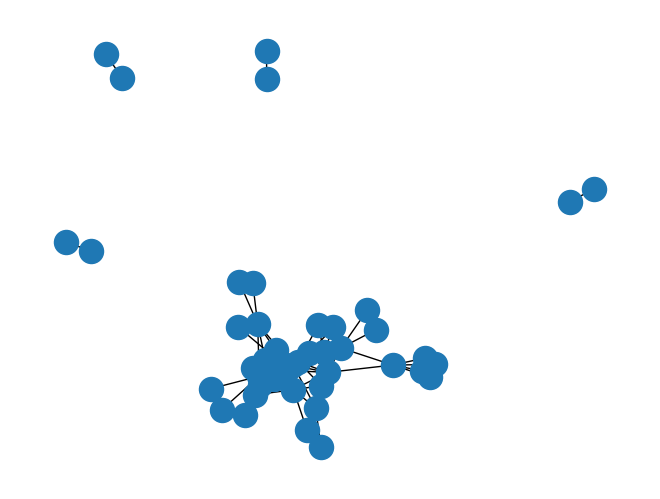

In [10]:
import networkx as nx
import matplotlib.pyplot as plt


nx.draw(H, with_labels=False)

# 4. Display the plot
plt.show()

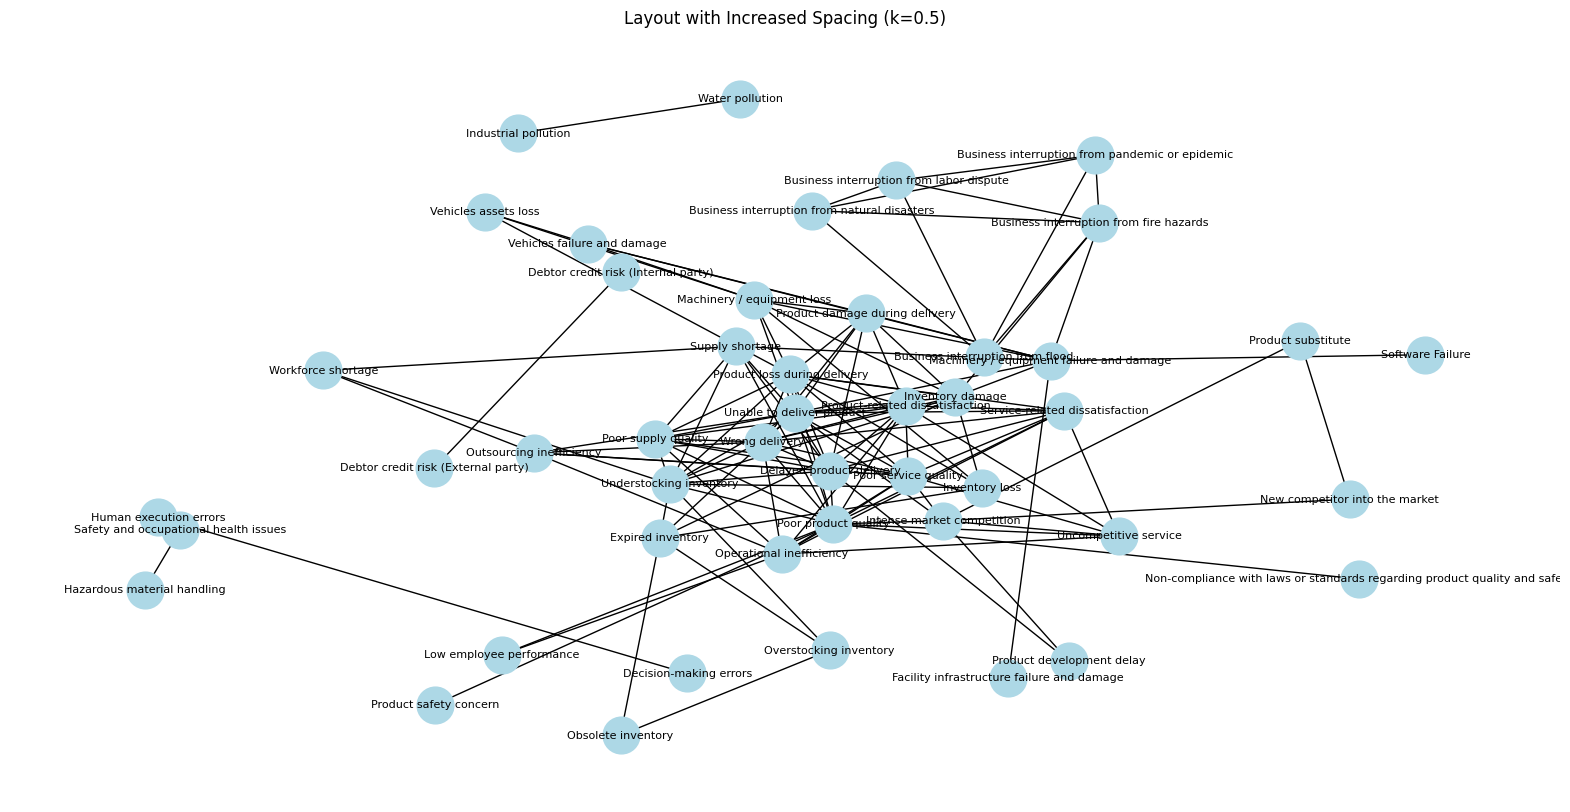

In [11]:
pos = nx.spring_layout(H, k=0.7)  # Increase k to 0.5 (default is 0.1)

plt.figure(figsize=(20, 10))  # This creates a larger 10x8 inch canvas
plt.title("Layout with Increased Spacing (k=0.5)")

# 3. Plot the graph and make the text smaller
# Use the 'font_size' argument to set the size of the node labels.
nx.draw(
    H,
    pos=pos,
    with_labels=True,
    node_color="lightblue",
    node_size=700,
    font_size=8,  # This makes the text smaller
)

# 4. Display the plot
plt.show()

In [12]:
H.edges()
# EdgeView(
#     [
#         ("Debtor credit risk (External party)", "Debtor credit risk (Internal party)"),
#         ...,
#     ]
# )

EdgeView([('Debtor credit risk (External party)', 'Debtor credit risk (Internal party)'), ('Product damage during delivery', 'Product loss during delivery'), ('Product damage during delivery', 'Unable to deliver product'), ('Product damage during delivery', 'Inventory damage'), ('Product damage during delivery', 'Wrong delivery'), ('Product damage during delivery', 'Delayed product delivery'), ('Product damage during delivery', 'Vehicles failure and damage'), ('Product damage during delivery', 'Product-related dissatisfaction'), ('Product damage during delivery', 'Machinery / equipment failure and damage'), ('Product damage during delivery', 'Machinery / equipment loss'), ('Product loss during delivery', 'Unable to deliver product'), ('Product loss during delivery', 'Wrong delivery'), ('Product loss during delivery', 'Delayed product delivery'), ('Product loss during delivery', 'Inventory loss'), ('Product loss during delivery', 'Product-related dissatisfaction'), ('Product loss during

In [13]:
old_G.edges()

EdgeView([('Debtor credit risk (External party)', 'Debtor credit risk (Internal party)'), ('Product damage during delivery', 'Product loss during delivery'), ('Product damage during delivery', 'Unable to deliver product'), ('Product damage during delivery', 'Inventory damage'), ('Product damage during delivery', 'Wrong delivery'), ('Product damage during delivery', 'Delayed product delivery'), ('Product damage during delivery', 'Vehicles failure and damage'), ('Product damage during delivery', 'Product-related dissatisfaction'), ('Product damage during delivery', 'Machinery / equipment failure and damage'), ('Product damage during delivery', 'Machinery / equipment loss'), ('Product loss during delivery', 'Unable to deliver product'), ('Product loss during delivery', 'Wrong delivery'), ('Product loss during delivery', 'Delayed product delivery'), ('Product loss during delivery', 'Inventory loss'), ('Product loss during delivery', 'Product-related dissatisfaction'), ('Product loss during

In [14]:
import networkx as nx


def normalize_edges(edge_list):
    """Normalizes a list of edges by sorting the nodes in each tuple.

    Args:
        edge_list: A list of tuples, where each tuple represents an edge.

    Returns:
        A set of frozensets, where each frozenset represents a normalized edge.
    """
    # Using frozenset allows for unhashable items (sets) to be elements of a set
    return {frozenset(edge) for edge in edge_list}


# Your example sets of edges
edgeView_A = [("A", "B"), ("A", "C"), ("B", "C")]
edgeView_B = [("C", "A"), ("C", "D"), ("D", "E")]

# Normalize the edges for correct set operations
normalized_A = normalize_edges(edgeView_A)
normalized_B = normalize_edges(edgeView_B)

# Find edges in A but not in B
diff_A_B = normalized_A - normalized_B

# Find edges in B but not in A
diff_B_A = normalized_B - normalized_A

print("Edges in A but not in B:")
print(diff_A_B)
print("\nEdges in B but not in A:")
print(diff_B_A)

Edges in A but not in B:
{frozenset({'B', 'A'}), frozenset({'C', 'B'})}

Edges in B but not in A:
{frozenset({'D', 'E'}), frozenset({'C', 'D'})}


In [15]:
# Normalize the edges for correct set operations
normalized_A = normalize_edges(old_G.edges())
normalized_B = normalize_edges(H.edges())

# Find edges in A but not in B
diff_A_B = normalized_A - normalized_B

# Find edges in B but not in A
diff_B_A = normalized_B - normalized_A

print("Edges in A but not in B:")
print(diff_A_B)
print("\nEdges in B but not in A:")
print(diff_B_A)

Edges in A but not in B:
{frozenset({'Operational inefficiency', 'Poor internal cooperation'}), frozenset({'Machinery / equipment loss', 'Hardware Failure'}), frozenset({'Industrial pollution', 'Hazardous chemicals and small particles'}), frozenset({'Vehicles failure and damage', 'Product loss during delivery'}), frozenset({'Facility infrastructure failure and damage', 'Business interruption from fire hazards'}), frozenset({'Loss of talent and expertise', 'Workforce shortage'}), frozenset({'Human execution errors', 'Operational inefficiency'}), frozenset({'Understocking inventory', 'Obsolete inventory'}), frozenset({'Overstocking inventory', 'Inventory loss'}), frozenset({'Vehicles assets loss', 'Inventory loss'}), frozenset({'Theft/Loss of Physical Media Containing Sensitive Data', 'Machinery / equipment loss'}), frozenset({'Product-related dissatisfaction', 'Low employee performance'}), frozenset({'Fluctuations in exchange rates', 'Fluctuations in interest rates'}), frozenset({'Risk 

In [16]:
len(H.edges()), len(old_G.edges())

(132, 132)

In [17]:
list_of_tuples_sorted_A_B = [tuple(sorted(edge)) for edge in diff_A_B]

list_of_tuples_sorted_B_A = [tuple(sorted(edge)) for edge in diff_B_A]
print("old thing have but not in new one")
print(len(list_of_tuples_sorted_A_B))
for edge in list_of_tuples_sorted_A_B:
    print(edge)

old thing have but not in new one
21
('Operational inefficiency', 'Poor internal cooperation')
('Hardware Failure', 'Machinery / equipment loss')
('Hazardous chemicals and small particles', 'Industrial pollution')
('Product loss during delivery', 'Vehicles failure and damage')
('Business interruption from fire hazards', 'Facility infrastructure failure and damage')
('Loss of talent and expertise', 'Workforce shortage')
('Human execution errors', 'Operational inefficiency')
('Obsolete inventory', 'Understocking inventory')
('Inventory loss', 'Overstocking inventory')
('Inventory loss', 'Vehicles assets loss')
('Machinery / equipment loss', 'Theft/Loss of Physical Media Containing Sensitive Data')
('Low employee performance', 'Product-related dissatisfaction')
('Fluctuations in exchange rates', 'Fluctuations in interest rates')
('Risk caused by Cyber Supply Chain Attack', 'Software Failure')
('Inventory loss', 'Obsolete inventory')
('Hazardous chemicals and small particles', 'Hazardous m

In [18]:
print("new thing have but not in old one")
print(len(list_of_tuples_sorted_B_A))
for edge in list_of_tuples_sorted_B_A:
    print(edge)

new thing have but not in old one
21
('Intense market competition', 'Poor service quality')
('Machinery / equipment loss', 'Unable to deliver product')
('Machinery / equipment failure and damage', 'Unable to deliver product')
('Operational inefficiency', 'Uncompetitive service')
('Intense market competition', 'Product development delay')
('Operational inefficiency', 'Service-related dissatisfaction')
('Machinery / equipment failure and damage', 'Supply shortage')
('Poor product quality', 'Supply shortage')
('Poor service quality', 'Product loss during delivery')
('Poor supply quality', 'Wrong delivery')
('Outsourcing inefficiency', 'Poor service quality')
('Delayed product delivery', 'Outsourcing inefficiency')
('Operational inefficiency', 'Poor supply quality')
('Intense market competition', 'Unable to deliver product')
('Poor service quality', 'Poor supply quality')
('Poor product quality', 'Understocking inventory')
('Operational inefficiency', 'Wrong delivery')
('Delayed product de

In [19]:
count = 0
for edge in list_of_tuples_sorted_B_A:
    # if one of node in priority_nodes skip
    if any(node in priority_nodes for node in edge):
        continue
    count += 1
    print(edge)
print(count)

('Machinery / equipment loss', 'Unable to deliver product')
('Machinery / equipment failure and damage', 'Unable to deliver product')
('Operational inefficiency', 'Uncompetitive service')
('Operational inefficiency', 'Service-related dissatisfaction')
('Machinery / equipment failure and damage', 'Supply shortage')
('Poor product quality', 'Supply shortage')
('Poor service quality', 'Product loss during delivery')
('Poor supply quality', 'Wrong delivery')
('Outsourcing inefficiency', 'Poor service quality')
('Delayed product delivery', 'Outsourcing inefficiency')
('Operational inefficiency', 'Poor supply quality')
('Poor service quality', 'Poor supply quality')
('Poor product quality', 'Understocking inventory')
('Operational inefficiency', 'Wrong delivery')
('Delayed product delivery', 'Service-related dissatisfaction')
('Poor supply quality', 'Understocking inventory')
('Poor supply quality', 'Product loss during delivery')
17


In [20]:
priority_nodes

['Intense market competition']

In [21]:
import networkx as nx
from networkx.algorithms.community import louvain_communities


clusters = louvain_communities(H)

# make sure to sort len member of each cluster by len of cluster
clusters.sort(key=lambda x: len(x), reverse=True)

In [22]:
clusters

[{'Delayed product delivery',
  'Low employee performance',
  'Non-compliance with laws or standards regarding product quality and safety',
  'Operational inefficiency',
  'Outsourcing inefficiency',
  'Poor product quality',
  'Poor service quality',
  'Poor supply quality',
  'Product safety concern',
  'Product-related dissatisfaction',
  'Service-related dissatisfaction',
  'Unable to deliver product',
  'Uncompetitive service',
  'Wrong delivery'},
 {'Facility infrastructure failure and damage',
  'Inventory damage',
  'Inventory loss',
  'Machinery / equipment failure and damage',
  'Machinery / equipment loss',
  'Product damage during delivery',
  'Product loss during delivery',
  'Software Failure',
  'Vehicles assets loss',
  'Vehicles failure and damage'},
 {'Expired inventory',
  'Obsolete inventory',
  'Overstocking inventory',
  'Supply shortage',
  'Understocking inventory',
  'Workforce shortage'},
 {'Business interruption from fire hazards',
  'Business interruption fr

In [23]:
{
    "Intense market competition",
    "New competitor into the market",
    "Product development delay",
    "Product substitute",
},

({'Intense market competition',
  'New competitor into the market',
  'Product development delay',
  'Product substitute'},)